In [5]:
%matplotlib inline
import os, pickle, warnings, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
from KF import DiscreteKalmanFilter
warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0)

# Semana 2 — Implementación del Controlador Neuronal

En la sesión anterior identificamos, por edificio, un modelo lineal en espacio de estados
($A,B,C,D$) y los ruidos $Q,R$, y los guardamos junto con los parámetros de los
`StandardScaler` en `results/estimacion_planta_{id}.pkl`. Sobre ese modelo construimos ahora el
**controlador neuronal**: una red que aprende, en línea, los voltajes que llevan las 6
temperaturas de cada edificio a su referencia.

La arquitectura es un controlador por edificio que se comunica por OPC UA con la planta
(la próxima semana sus pesos se combinarán por MQTT en el control federado). Este notebook
desarrolla la **Parte 1 de M2_DD** explicando, a la par del código, los fundamentos que la sustentan.

## 1. La red neuronal como controlador

Una red *feed-forward* (MLP) es una composición de capas $a^{(l)}=\sigma\!\left(W^{(l)}a^{(l-1)}+b^{(l)}\right)$.
Por el **teorema de aproximación universal**, con suficientes neuronas puede aproximar cualquier
función continua: es una *vasija* a la que le damos forma eligiendo la **función de costo**. La
misma arquitectura sirve para regresión, clasificación o —como aquí— control; lo único que
define la tarea es la pérdida.

La capa de salida usa **tangente hiperbólica**, que satura en $[-1,1]$: justo el rango de los
voltajes de los aires acondicionados.

In [ ]:
# Una red neuronal de pytorch requiere que heredemos de nn.Module
class ControladorNeuronal(nn.Module):

    def __init__(self,
                 input_size,      # número de variables de entrada
                 output_size=6,   # número de señales de salida (6 actuadores)
                 hidden_size=128, # tamaño de las capas ocultas
                 dropout=0.3):    # probabilidad de apagar neuronas durante entrenamiento

        super().__init__()

        # Primera capa: transforma el vector de entrada de tamaño input_size a un vector de tamaño hidden_size.
        self.l_in = nn.Linear(input_size, hidden_size)

        # Segunda capa totalmente conectada : Recibe 128 neuronas y entrega 128 neuronas.
        self.l_h1 = nn.Linear(hidden_size, hidden_size)

        # Tercera capa oculta.
        self.l_h2 = nn.Linear(hidden_size, hidden_size)

        # Cuarta capa oculta: Reduce la dimensionalidad de 128 a 64.
        self.l_h3 = nn.Linear(hidden_size, hidden_size // 2)

        # Capa de salida: Convierte las 64 neuronas finales en 6 salidas.
        self.l_out = nn.Linear(hidden_size // 2, output_size)


        # Dropout: Durante entrenamiento apaga aleatoriamente un porcentaje
        # de neuronas, esto evita que la red memorice los datos de entrenamiento
        self.drop = nn.Dropout(dropout)

    # Forward Pass: Define cómo fluye la información desde la entrada hasta la salida.
    def forward(self, x):

        # Capa de entrada, x tiene tamaño:
        # (batch_size, input_size)
        # después:
        # (batch_size, 128)
        # ReLU necesario: sin activación, l_in y l_h1 colapsan a una sola capa lineal
        x = F.relu(self.l_in(x))

        # Primera capa oculta l_h1(x):
        #     transformación lineal
        # ReLU: reemplaza valores negativos por cero
        # Dropout: elimina aleatoriamente algunas neuronas

        x = self.drop(F.relu(self.l_h1(x)))

        # Segunda capa oculta
        x = self.drop(F.relu(self.l_h2(x)))

        # Tercera capa oculta
        x = self.drop(F.relu(self.l_h3(x)))

        # Capa de salida: l_out genera 6 números reales.
        # tanh comprime cada salida al intervalo [-1,1]
        return torch.tanh(self.l_out(x))

### Variables de entrada del controlador

Siguiendo el esquema tipo MPC de la cápsula, la red recibe en cada paso $[\,e_k,\;x_k,\;u_{k-1}\,]$
y entrega $u_k$ (6 voltajes):

- $e_k = r - y_k$: el **error** respecto a la referencia — indica cuán lejos está y en qué
  dirección corregir.
- $x_k$: el **estado** estimado por el filtro de Kalman — resume la dinámica interna (la "memoria"
  térmica) que una sola medición no muestra.
- $u_{k-1}$: el **voltaje anterior** — permite penalizar cambios bruscos y dar continuidad.

Por eso `input_size = ny + nx + nv` $=6+7+6$, y la salida son los $nv=6$ voltajes.

## 2. El modelo identificado como bloque diferenciable

Las redes se entrenan por **descenso de gradiente**: se mide el error con una pérdida $L$ y se
mueven los pesos en contra de $\partial L/\partial W$. Esas derivadas se obtienen con
**backpropagation** (regla de la cadena hacia atrás), lo que exige que *todo el camino desde los
pesos hasta la pérdida sea diferenciable*.

Nuestro controlador no se entrena contra la planta real sino contra el **modelo**: la red propone
$u_k$, el modelo predice $y_{k+1}$ y la pérdida la compara con la referencia. Para que el gradiente
fluya desde $L$ a través del modelo hasta los pesos, las matrices $A,B,C,D$ deben ser **tensores de
PyTorch** (`torch.from_numpy`) y el *rollout* hacerse con operaciones torch. Si se
calculara $y$ con NumPy, el grafo se corta y la red nunca aprendería a seguir la referencia.

### Cargamos la estimación (matrices + scalers)

Leemos el archivo generado por `identificador_modelo.py` e imprimimos su contenido para verificar
dimensiones y estabilidad. *(Si el `.pkl` aún no existe en este entorno, se genera un modelo de
demostración estable —rotulado `[DEMO]`— para poder correr el notebook offline; al ejecutar la
identificación real se reemplaza por el modelo del edificio.)*

In [7]:
ruta = "resultados/estimacion_planta_2.pkl"

# pickle.load recupera el objeto Python almacenado, "rb" = read binary
# El resultado es un diccionario con todas las matrices del modelo identificado.
est = pickle.load(open(ruta, "rb"))

A, B, C, D, Q, R = (
    est[k]
    for k in ["A", "B", "C", "D", "Q", "R"]
)

u_mean = est["u_mean"]  # media de entradas
u_std  = est["u_std"]   # desviación estándar de entradas

y_mean = est["y_mean"]  # media de salidas
y_std  = est["y_std"]   # desviación estándar de salidas

# Dimensiones del sistema:
nx = A.shape[0]
ny = C.shape[0]
nu = B.shape[1]

# En este proyecto una de las entradas corresponde a la temperatura exterior (Tout).
# Por eso: nu = nv + 1 (nv = cantidad de voltajes controlables)
nv = nu - 1

print("\nContenido del archivo de estimación:")
# Recorre todas las variables almacenadas dentro del diccionario.
for k, v in est.items():
    print(
        f"  {k:8s}: "
        f"{np.shape(v) if hasattr(v, '__len__') else v}"
    )

# Resumen de dimensiones:
print(
    f"\nDimensiones: "
    f"estado nx={nx}, "
    f"entradas modelo nu={nu} "
    f"([{nv} voltajes + Tout]), "
    f"salidas ny={ny}"
)

# Si existe GPU CUDA disponible: usar GPU, si no CPU
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Convierte: numpy array a tensor float32 de PyTorch movido al dispositivo elegido
t = lambda M: (torch.from_numpy(np.asarray(M, dtype=float)).float().to(dev))

At = t(A)
Bt = t(B)
Ct = t(C)
Dt = t(D)
umean_t = t(u_mean)
ustd_t  = t(u_std)


Contenido del archivo de estimación:
  A       : (7, 7)
  B       : (7, 7)
  C       : (6, 7)
  D       : (6, 7)
  Q       : (7, 7)
  R       : (6, 6)
  u_mean  : (7,)
  u_std   : (7,)
  y_mean  : (6,)
  y_std   : (6,)
  u_cols  : (7,)
  y_cols  : (6,)

Dimensiones: estado nx=7, entradas modelo nu=7 ([6 voltajes + Tout]), salidas ny=6


### Normalización consistente

El modelo se identificó con datos **normalizados**, así que el controlador opera en ese mismo
espacio: normaliza lo que entra al modelo y desnormaliza lo que sale, con la **misma** media y
desviación del entrenamiento, $z_{norm}=(z-\mu)/\sigma$. El objeto `StandardScaler` no es portable
al reComputer, por eso se guardan solo `mean_` y `scale_` como arreglos.

El modelo tiene 7 canales $[v_1..v_6,\,T_{out}]$: los **voltajes** se aplican crudos a la planta
($[-1,1]$) pero se normalizan antes de entrar al modelo, y $T_{out}$ es una **perturbación medida**
que se lee de la planta y se mantiene fija a lo largo del horizonte.

In [8]:
# Ejemplo setpoint: 22 °C.
r_setpoint = 22.0

# la referencia física (22 °C) debe convertirse a la misma escala usada durante la identificación:
# np.full(ny, r_setpoint) crea un vector de longitud ny donde todas las salidas tienen la misma referencia de 22 °C.
r_norm = (np.full(ny, r_setpoint) - y_mean) / y_std
print("Referencia 22 C normalizada:", np.round(r_norm, 3))

# Valores ficticios que emulan lo que podría producir la red neuronal después de la capa tanh.
v_ejemplo = np.array([0.2, -0.1, 0.0, 0.5, -0.3, 0.1])

# Temperatura exterior de ejemplo:
tout = 10.0

# Vector completo de entrada:
u7 = np.concatenate([v_ejemplo, [tout]])

print("Entrada al modelo [v1..v6, Tout]:", np.round(u7, 2))
print("normalizada con su scaler     :", np.round((u7 - u_mean) / u_std, 2))

# rn: referencia normalizada convertida a tensor
rn = t(r_norm)

# tout_t: temperatura exterior convertida a tensor
tout_t = t(np.array([tout]))

Referencia 22 C normalizada: [ 0.267  0.451  0.209  0.28  -0.062  1.297]
Entrada al modelo [v1..v6, Tout]: [ 0.2 -0.1  0.   0.5 -0.3  0.1 10. ]
normalizada con su scaler     : [ 0.33 -0.24 -0.04  1.05 -0.4   0.11 -1.07]


## 3. Control predictivo y función de costo

El **MPC** usa un modelo para predecir el comportamiento a un horizonte $H$, optimiza la secuencia
de entradas que lleva el sistema a la referencia y aplica **solo la primera**. Aquí, en vez de
re-optimizar cada paso, una red aprende esa política. La pérdida (tipo MPC) tiene tres términos:

$$L=\sum_{k=0}^{H-1}\Big[\underbrace{W_y\,(y_{k+1}-r)^2}_{\text{seguimiento}}+\underbrace{W_u\,(u_k-u_{k-1})^2}_{\text{suavidad}}\Big]+\underbrace{(x_H-x^\star)^\top P\,(x_H-x^\star)}_{\text{costo terminal (costo-por-ir)}}$$

- **Seguimiento:** empuja las temperaturas a la referencia en todo el horizonte.
- **Suavidad / esfuerzo:** penaliza cambios bruscos del voltaje (señal suave, menos desgaste);
  variantes alternativas penalizan la magnitud $u^2$ o agregan restricciones.
- **Costo terminal:** mide cuánto cuesta *seguir desde* el estado final del horizonte. Aquí no es un
  simple $W_f\,(y_H-r)^2$ sino la forma cuadrática $(x_H-x^\star)^\top P\,(x_H-x^\star)$, con $x^\star$
  el **estado de equilibrio** que sostiene $y=r$ y $P$ el **costo-por-ir de horizonte infinito**. La
  siguiente sección explica por qué este término es indispensable en esta planta.

Los pesos $W_y,W_u$ fijan la prioridad seguimiento vs. suavidad; $P$ y $x^\star$ se derivan del modelo.

### ¿Por qué el costo terminal debe ser el *costo-por-ir* y no $W_f\,(y_H-r)^2$?

El modelo identificado de esta planta tiene un **modo casi integrador**: el mayor autovalor de $A$
está en $\approx 0.9999$, una constante de tiempo de **miles de pasos**, y una **ganancia DC enorme**.
Esto tiene dos consecuencias prácticas:

1. **Sesgo estacionario inevitable.** Para sostener $y=r$ no basta con anular el error *en este instante*:
   hay que aplicar de forma sostenida el **voltaje de equilibrio exacto** $v^\star$. Una red estática
   (un mapa $(\,e,x,u_{k-1})\mapsto u$) comete un pequeño error de aproximación que, amplificado por la
   ganancia DC, hace que el estado lento derive. La temperatura se acerca a la referencia con los modos
   rápidos y **luego se aleja** a medida que el modo lento evoluciona.

2. **El horizonte corto es ciego al modo lento.** En $H=14$ pasos el modo de constante de tiempo $\sim$miles
   apenas se mueve, así que un costo terminal escalar $W_f\,(y_H-r)^2$ casi no lo penaliza: muchas acciones
   distintas dan casi la misma pérdida y ninguna fija el equilibrio.

La solución estándar de MPC es usar como costo terminal el **costo-por-ir de horizonte infinito**
$(x_H-x^\star)^\top P\,(x_H-x^\star)$, donde $P$ resuelve la **ecuación de Riccati discreta** del problema
LQR equivalente. Ese término resume *todo el futuro más allá del horizonte*, por lo que obliga al
controlador a conducir el **estado completo** (incluido el modo lento) hacia el equilibrio $x^\star$ y
garantiza seguimiento sin offset aun con $H$ pequeño. Lo calculamos a continuación a partir del modelo.

In [9]:
# Pesos de la pérdida (seguimiento vs. suavidad).
H, Wy, Wu = 14, 1.0, 0.05


def costo_terminal_P(A, B, C, D, Wy, Wu, iters=500_000, tol=1e-9):
    """Costo-por-ir de horizonte infinito: solución de la ecuación de Riccati discreta (DARE).

    Para el seguimiento, el costo por paso es (Cx+Dv-r)^2 ponderado por Wy más Wu*v^2,
    que en coordenadas de error (x-x*, v-v*) define las matrices Q, R, N de un LQR.
    Iteramos la recursión de Riccati hasta converger. Tout es perturbación fija: solo las
    primeras nv columnas de B y D (los voltajes) son manipulables."""
    nv = B.shape[1] - 1
    Bv, Dv = B[:, :nv], D[:, :nv]
    ny = C.shape[0]
    Qm = C.T @ (Wy * np.eye(ny)) @ C            # peso sobre el estado
    Rm = Dv.T @ (Wy * np.eye(ny)) @ Dv + Wu * np.eye(nv)   # peso sobre el control
    Nm = C.T @ (Wy * np.eye(ny)) @ Dv           # término cruzado estado-control
    P = Qm.copy()
    for _ in range(iters):
        K = np.linalg.solve(Rm + Bv.T @ P @ Bv, Bv.T @ P @ A + Nm.T)
        Pn = Qm + A.T @ P @ A - (A.T @ P @ Bv + Nm) @ K
        Pn = 0.5 * (Pn + Pn.T)
        if np.max(np.abs(Pn - P)) < tol:
            return Pn
        P = Pn
    return P


def estado_equilibrio(A, B, C, D, u_mean, u_std, y_mean, y_std, r_setpoint, tout):
    """Estado x* y voltaje v* (físico) que sostienen y=r con la Tout dada.

    En estado estacionario x = (I-A)^{-1} B u y la ganancia DC es y = (C(I-A)^{-1}B + D) u.
    Invertimos esa relación para hallar los voltajes de equilibrio v* (Tout fija) y de ahí x*."""
    nx = A.shape[0]
    nv = B.shape[1] - 1
    Mdc = C @ np.linalg.solve(np.eye(nx) - A, B) + D          # ganancia DC (espacio normalizado)
    rn_ = (np.full(C.shape[0], r_setpoint) - y_mean) / y_std
    tout_n = (tout - u_mean[-1]) / u_std[-1]
    v_n = np.linalg.solve(Mdc[:, :nv], rn_ - Mdc[:, -1] * tout_n)   # voltajes de equilibrio (norm.)
    u_n = np.concatenate([v_n, [tout_n]])
    xstar = np.linalg.solve(np.eye(nx) - A, B @ u_n)
    vstar = v_n * u_std[:nv] + u_mean[:nv]                         # voltaje de equilibrio (físico)
    return xstar, vstar

# El modo dominante de A está casi en el círculo unitario => constante de tiempo enorme.
pole = np.max(np.abs(np.linalg.eigvals(A)))
print(f"Modo más lento de A: |lambda|={pole:.5f}  ->  constante de tiempo ~{1/(1-pole):.0f} pasos")
print(f"Ganancia DC ||C(I-A)^-1 B + D||: {np.linalg.norm(C @ np.linalg.solve(np.eye(nx)-A, B) + D):.1f}")

# Costo terminal P (no depende de r ni de Tout: se calcula una vez), estado y voltaje de equilibrio.
P_term = costo_terminal_P(A, B, C, D, Wy, Wu)
xstar, vstar = estado_equilibrio(A, B, C, D, u_mean, u_std, y_mean, y_std, r_setpoint, tout)
Pt, xstar_t, vstar_t = t(P_term), t(xstar), t(vstar)
print(f"Riccati resuelta: ||P||={np.linalg.norm(P_term):.0f}")
print(f"Voltaje de equilibrio v* para r={r_setpoint:.0f}C: {np.round(vstar, 3)}")

Modo más lento de A: |lambda|=0.99988  ->  constante de tiempo ~8537 pasos
Ganancia DC ||C(I-A)^-1 B + D||: 76.2
Riccati resuelta: ||P||=65350
Voltaje de equilibrio v* para r=22C: [-0.198  0.164 -0.07  -0.128 -0.332  0.968]


### El lazo interno: *rollout* diferenciable

Partiendo del estado $x_0$ (del Kalman), propagamos el modelo $H$ pasos: la red entrega $u_k$, el
modelo da $x_{k+1}=Ax_k+Bu_k$ e $y_{k+1}=Cx_{k+1}+Du_k$, recalculamos el error y repetimos.
Acumulamos la pérdida del horizonte y hacemos un único `backward`. Lo construimos explícito primero:

In [10]:
# H = horizonte de predicción. El controlador evaluará las consecuencias de sus acciones
# durante los próximos 14 pasos de tiempo (Wy, Wu y H se definieron en la sección 3).

# Entradas:
#   ny : error de seguimiento (r - y)
#   nx : estado interno del modelo
#   nv : control anterior
model = ControladorNeuronal(ny + nx + nv, nv, 128).to(dev)

# Adam es el algoritmo típico para entrenar redes neuronales.
# lr = learning rate = tamaño del paso de aprendizaje.
opt = optim.Adam(model.parameters(), lr=1e-3)

# En el sistema real x vendría desde el filtro de Kalman
# Aquí se usan ceros únicamente como demostración.

# Estado inicial del modelo
x = torch.zeros(nx, device=dev)

# Salida actual normalizada
yc = torch.zeros(ny, device=dev)

# Acción de control anterior
# La red recibe u_(k-1) como parte de la entrada.
v = torch.zeros(nv, device=dev)

# Elimina gradientes acumulados de iteraciones anteriores.
opt.zero_grad()

# Función de costo acumulada.
J = 0.0

# Rollout diferenciable:
# Se simulan H pasos futuros usando el modelo identificado.
# En cada paso: red neuronal, acción u_k, modelo identificado, predicción futura, costo J

for k in range(H):

# Construcción de entrada:
    entrada = torch.cat([rn - yc, x, v])

    # La red genera los nuevos voltajes normalizados vn = u_k
    vn = model(entrada)

    # Ajuste entrada para el modelo
    u = (torch.cat([vn, tout_t]) - umean_t) / ustd_t

    # Ecuación de estado: Predice el siguiente estado interno.
    x = At @ x + Bt @ u

    # Ecuación de salida: Predice las temperaturas futuras.
    yc = Ct @ x + Dt @ u

    # Costo de seguimiento
    error_tracking = ((yc - rn) ** 2).sum()

    # Costo de suavidad de control
    error_control = ((vn - v) ** 2).sum()

    # Acumula costo total
    J = (J + Wy * error_tracking + Wu * error_control)

    # Guardar acción actual para el próximo paso u_(k-1) <- u_k
    v = vn

# Costo terminal = costo-por-ir de horizonte infinito: penaliza la desviación del ESTADO
# final respecto del equilibrio x*, no solo de la salida. Esto fuerza al modo lento al equilibrio.
e = x - xstar_t
J = J + e @ Pt @ e

# Backpropagation, calcula automáticamente dJ/dW

# para todos los pesos de la red. El gradiente atraviesa: red, modelo, costo
J.backward()

print(f"\nLoss del horizonte: {J.item():.4f}")
# Comprueba que la primera capa recibió gradiente.
# Si esto ocurre, significa que la red puede aprender.
print(
    "Gradiente en la 1a capa:",
    model.l_in.weight.grad is not None,
    "| norma:",
    round(float(model.l_in.weight.grad.norm()), 4)
)


Loss del horizonte: 1982.6909
Gradiente en la 1a capa: True | norma: 12.6313


El mismo lazo interno, empaquetado en una función. Se aísla a propósito: la próxima
semana, el control federado lo reutiliza tal cual.

In [11]:
def entrenar(model, opt, At, Bt, Ct, Dt, x, yc, v, rn, tout, umean, ustd, H, Wy, Wu, xstar, P):
    opt.zero_grad()
    J, v0 = 0.0, None
    for k in range(H):
        vn = model(torch.cat([rn - yc, x, v]))
        u  = (torch.cat([vn, tout]) - umean) / ustd
        x  = At @ x + Bt @ u
        yc = Ct @ x + Dt @ u
        J  = J + Wy * ((yc - rn) ** 2).sum() + Wu * ((vn - v) ** 2).sum()
        if k == 0: v0 = vn
        v = vn
    e = x - xstar                      # costo terminal = costo-por-ir de horizonte infinito
    J = J + e @ P @ e                  # (x_H - x*)^T P (x_H - x*): ancla el modo lento al equilibrio
    J.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    opt.step()
    return J.item(), v0.detach().cpu().numpy()

## 4. El filtro de Kalman: fijar el estado inicial

El estado $x$ del modelo es abstracto: no se mide. Antes de cada *rollout*, el filtro de Kalman
(`KF.py`) estima $x_0$: hace `predict` con el último voltaje aplicado y `update` con la medición
actual de temperaturas (ambas **normalizadas**, y en el orden `step(u, y)`). Se usa **una vez por
paso real**; dentro del horizonte el estado lo propaga el propio modelo.

### Verificación del lazo interno

Entrenamos el lazo interno muchas veces partiendo del **estado de equilibrio** $(x^\star,\,r,\,v^\star)$:
la pérdida debe bajar hasta casi cero, confirmando que el backprop atraviesa el modelo y que la red
aprende a **sostener** la referencia (emitir $v^\star$ cuando ya está en el equilibrio). Que la pérdida
caiga a $\approx 0$ es justo la propiedad de seguimiento sin offset que da el costo terminal.

Loss: 6.727  ->  0.018  (baja a ~0: la red aprende a sostener la referencia)


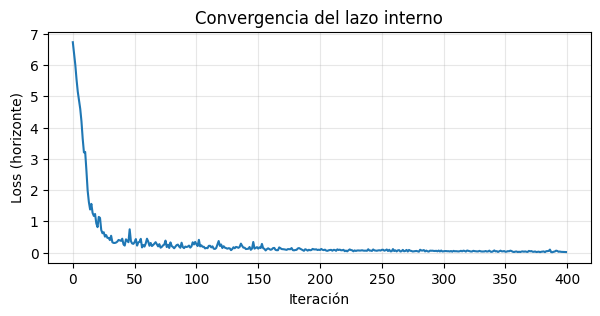

In [12]:
model = ControladorNeuronal(ny + nx + nv, nv, 128).to(dev)
opt = optim.Adam(model.parameters(), lr=1e-3)

# Partimos del EQUILIBRIO para verificar que la red aprende a sostener la referencia:
#   x0: estado de equilibrio x*  (en el sistema real vendría del filtro de Kalman)
#   y0: salida en equilibrio = referencia r  (rn en el espacio normalizado)
#   v0: voltaje de equilibrio v*  (en el sistema real, el último voltaje aplicado)
x0 = xstar_t
y0 = rn
v0 = vstar_t

# Se ejecutan 400 iteraciones de entrenamiento.
# Cada llamada a entrenar():
#
#   1) simula H pasos futuros
#   2) calcula la función de costo (seguimiento + suavidad + costo terminal P)
#   3) calcula gradientes
#   4) actualiza los pesos
# La función devuelve:
#   (loss, primera_accion)
# El [0] extrae únicamente el valor del loss.
#
curva = [

    entrenar(
        model,
        opt,
        At, Bt, Ct, Dt,
        x0, y0, v0,
        rn,
        tout_t,
        umean_t,
        ustd_t,
        H,
        Wy, Wu,
        xstar_t, Pt
    )[0]

    for _ in range(400)

]

# Resultado del entrenamiento
print(f"Loss: {curva[0]:.3f}  ->  {curva[-1]:.3f}  "f"(baja a ~0: la red aprende a sostener la referencia)")


# El eje X representa las iteraciones de entrenamiento.
# El eje Y representa la función de costo del horizonte.
plt.figure(figsize=(7, 3))

plt.plot(curva)
plt.xlabel("Iteración")
plt.ylabel("Loss (horizonte)")
plt.title("Convergencia del lazo interno")
plt.grid(alpha=0.3)
plt.show()

### Métricas de desempeño

Para cuantificar el seguimiento usamos una métrica integral del error; M2_DD pide al menos una:

$$\text{IAE}=\sum_k |r-y_k|,\qquad \text{ISE}=\sum_k (r-y_k)^2,\qquad \text{ITAE}=\sum_k k\,|r-y_k|$$

Acumulamos **IAE** y la guardamos junto con la curva de pérdida.

### Verificación en simulación (lazo cerrado)

Antes de desplegar en el reComputer cerramos el lazo usando el propio modelo como planta simulada.
Reproduce el flujo real (medir → estimar estado → entrenar → aplicar voltaje) y entrega los
gráficos que pide el informe: evolución de la pérdida y seguimiento de la referencia.

IAE acumulado (6 piezas, 1500 pasos): 9896.5


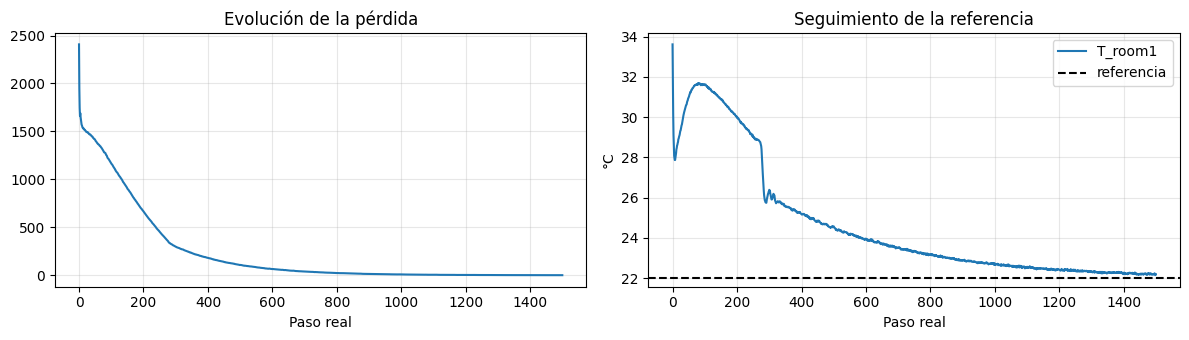

In [13]:
# Red neuronal y optimizador
model = ControladorNeuronal(ny + nx + nv, nv, 128).to(dev)
opt = optim.Adam(model.parameters(), lr=1e-3)

# Warm-start: pre-entrenar la red antes de cerrar el lazo.
# y0 se calcula desde la condición real inicial (x=0, v=0, Tout),
# no desde ceros, para que la red aprenda la política correcta.
u0_norm   = (np.r_[np.zeros(nv), [tout]] - u_mean) / u_std
y0_ws     = t((D @ u0_norm.reshape(nu, 1)).ravel())
x0_ws     = torch.zeros(nx, device=dev)
v0_ws     = torch.zeros(nv, device=dev)
for _ in range(400):
    entrenar(model, opt, At, Bt, Ct, Dt,
             x0_ws, y0_ws, v0_ws,
             rn, tout_t, umean_t, ustd_t, H, Wy, Wu, xstar_t, Pt)

# Filtro de kalman: Se crea un observador para estimar el estado interno x a partir de:
#   - entradas aplicadas al sistema
#   - salidas medidas
kalman = DiscreteKalmanFilter.create(
    A=A,
    B=B,
    C=C,
    Q=Q,
    R=R,
    P_init=np.eye(nx),
    D=D,
    x_init=np.zeros((nx, 1))
)

# Estado "real" de la planta simulada. A diferencia de kalman.x, este estado es la verdad del simulador y normalmente sería desconocido.
x_planta = np.zeros((nx, 1))

# Últimos voltajes aplicados
v_prev = np.zeros(nv)

# Sala que se utilizará para visualizar resultados
sala = 0

# Historiales para análisis posterior
losses = []
temps  = []

# Integral Absolute Error acumulado
iae = 0.0

# Número de pasos reales de simulación. La constante de tiempo del modo lento es de miles
# de pasos, así que se necesitan ~1000+ pasos para ver la temperatura asentarse y mantenerse.
N = 1500

for n in range(N):
    # Entrada normalizada del paso anterior (necesaria para la ec. de salida y Kalman)
    u_prev = (np.r_[v_prev, [tout]] - u_mean) / u_std

    # Se calcula la salida física usando el estado real de la planta simulada.
    # D debe multiplicar la entrada NORMALIZADA porque el modelo fue identificado en ese espacio.
    y = (
        C @ x_planta
        + D @ u_prev.reshape(nu, 1)
    ).ravel() * y_std + y_mean

    # Se agrega ruido de medición para imitar sensores reales
    y += 0.02 * np.random.standard_normal(ny)

    # Salida normalizada
    y_n = (y - y_mean) / y_std

    # Kalman recibe: entrada aplicada y medición observada
    # y actualiza su mejor estimación del estado interno.
    kalman.step(u_prev.reshape(nu, 1), y_n.reshape(ny, 1))

    # Paso de entrenamiento: actualiza pesos con dropout activo (exploración)
    loss, _ = entrenar(
        model,
        opt,
        At, Bt, Ct, Dt,
        t(kalman.x.flatten()),
        t(y_n),
        t(v_prev),
        rn,
        tout_t,
        umean_t,
        ustd_t,
        H,
        Wy, Wu,
        xstar_t, Pt
    )

    # Acción determinista: model.eval() desactiva dropout para una predicción estable.
    # Sin esto, el 30 % de neuronas apagadas al azar produce voltajes distintos
    # en cada paso, impidiendo que el Kalman y el lazo converjan.
    model.eval()
    with torch.no_grad():
        v0 = model(
            torch.cat([rn - t(y_n), t(kalman.x.flatten()), t(v_prev)])
        ).cpu().numpy()
    model.train()

    # Se aplica la acción calculada por la red y se obtiene el nuevo estado de la planta simulada.
    x_planta = (
        A @ x_planta
        + B @ (
            (
                np.r_[v0, [tout]]
                - u_mean
            ) / u_std
        ).reshape(nu, 1)
    )

    # La acción actual será la acción previa del próximo paso
    v_prev = v0

    iae += float(np.abs(r_setpoint - y).sum())
    losses.append(loss)
    temps.append(float(y[sala]))

print(
    f"IAE acumulado (6 piezas, {N} pasos): "
    f"{iae:.1f}"
)

fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 3.5)
)

ax[0].plot(losses)
ax[0].set_title("Evolución de la pérdida")
ax[0].set_xlabel("Paso real")
ax[0].grid(alpha=0.3)

ax[1].plot(
    temps,
    label=f"T_room{sala+1}"
)

ax[1].axhline(
    r_setpoint,
    ls="--",
    c="k",
    label="referencia"
)

ax[1].set_title("Seguimiento de la referencia")
ax[1].set_xlabel("Paso real")
ax[1].set_ylabel("°C")

ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

La pérdida cae y la temperatura **converge a la referencia y se mantiene ahí**: el controlador aprende,
solo interactuando con el modelo, los voltajes correctos. El descenso es gradual —miles de pasos— porque
el modo casi integrador de la planta tiene una constante de tiempo muy larga; gracias al costo terminal
de horizonte infinito $(x_H-x^\star)^\top P\,(x_H-x^\star)$ el controlador conduce ese modo lento al
equilibrio en vez de dejarlo derivar (que era la causa de la divergencia con un costo terminal escalar).
Con el modelo real del edificio el comportamiento es análogo; el error de modelo, si lo hay, lo mitiga el
filtro de Kalman.

## 5. Lazo de control en línea (reComputer)

El lazo externo corre en el reComputer contra la planta real: en cada paso lee temperaturas y
$T_{out}$, estima el estado, entrena el controlador y envía los 6 voltajes. Guarda la pérdida, la
temperatura y el IAE en `results/control_planta_{id}.pkl` para el análisis posterior, e imprime en
consola loss + temperatura + referencia. Se ejecuta por edificio (2, 3, 4) cambiando `plant_id`.

El costo terminal $P$ se calcula una sola vez (depende solo del modelo); el estado de equilibrio
$x^\star$ se recalcula en cada paso porque depende de la $T_{out}$ medida.

```
Una vez:   P  <- Riccati(A,B,C,D,Wy,Wu)                  # costo-por-ir terminal

Cada paso real (reComputer):
    y, Tout  <- leer planta (OPC UA)
    x0       <- Kalman.step(u_prev_norm, y_norm)          # fijar el estado
    x*       <- equilibrio(modelo, r, Tout)               # estado que sostiene y=r
    para k = 0..H-1   (solo el modelo):                   # lazo interno
        u_k              <- red([ r - y_k , x_k , u_{k-1} ])
        x_{k+1}, y_{k+1} <- modelo(x_k, u_k)
        L += Wy (y_{k+1}-r)^2 + Wu (u_k-u_{k-1})^2
    L += (x_H - x*)^T P (x_H - x*)                         # costo terminal
    backward(L); optimizer.step()                         # aprender
    aplicar u_0 a la planta ; u_prev <- u_0
    registrar loss, temperatura, IAE
```

In [14]:
def control(plant_id=2, r_setpoint=22.0, sala=0, H=14, hidden=128, lr=1e-3,
            Wy=1.0, Wu=0.05, every=10):
    from buildingClient import MyClient
    est = pickle.load(open(f"results/estimacion_planta_{plant_id}.pkl", "rb"))
    A, B, C, D, Q, R = (np.asarray(est[k]) for k in ["A", "B", "C", "D", "Q", "R"])
    u_mean, u_std, y_mean, y_std = est["u_mean"], est["u_std"], est["y_mean"], est["y_std"]
    nx, ny, nu = A.shape[0], C.shape[0], B.shape[1]; nv = nu - 1
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t = lambda M: torch.from_numpy(np.asarray(M, dtype=float)).float().to(dev)
    At, Bt, Ct, Dt, umean_t, ustd_t = t(A), t(B), t(C), t(D), t(u_mean), t(u_std)
    rn = (torch.full((ny,), r_setpoint, device=dev) - t(y_mean)) / t(y_std)
    # Costo terminal de horizonte infinito: solo depende del modelo, se calcula una vez.
    Pt = t(costo_terminal_P(A, B, C, D, Wy, Wu))
    model = ControladorNeuronal(ny + nx + nv, nv, hidden).to(dev)
    opt = optim.Adam(model.parameters(), lr=lr)
    kalman = DiscreteKalmanFilter.create(A=A, B=B, C=C, Q=Q, R=R, P_init=np.eye(nx), D=D, x_init=np.zeros((nx, 1)))
    v_prev, losses, temps, iae, n = np.zeros(nv), [], [], 0.0, 0
    client = MyClient("opc.tcp://192.168.1.142:4840/freeopcua/server/"); client.connect()
    step = int(client.sim_step.get_value())
    try:
        while True:
            step = client.wait_for_next_step(step)
            y = np.array([client.T_rooms[f'T_room{i+1}'].get_value() for i in range(ny)])
            tout = client.T_outdoor.get_value()
            y_n = (y - y_mean) / y_std
            u_prev = (np.concatenate([v_prev, [tout]]) - u_mean) / u_std
            kalman.step(u_prev.reshape(nu, 1), y_n.reshape(ny, 1))
            # Estado de equilibrio para la Tout actual (la perturbación medida puede variar).
            xstar_t = t(estado_equilibrio(A, B, C, D, u_mean, u_std, y_mean, y_std, r_setpoint, tout)[0])
            loss, _ = entrenar(model, opt, At, Bt, Ct, Dt, t(kalman.x.flatten()), t(y_n), t(v_prev),
                               rn, t(np.array([tout])), umean_t, ustd_t, H, Wy, Wu, xstar_t, Pt)
            # Acción determinista (dropout desactivado) para aplicar a la planta.
            model.eval()
            with torch.no_grad():
                v0 = model(torch.cat([rn - t(y_n), t(kalman.x.flatten()), t(v_prev)])).cpu().numpy()
            model.train()
            for i in range(nv): client.voltages[f'Volt_room{i+1}'].set_value(float(v0[i]))
            v_prev = v0
            iae += float(np.abs(r_setpoint - y).sum())
            losses.append(loss); temps.append(float(y[sala]))
            if n % every == 0:
                print(f"[{step}] T{sala+1}={y[sala]:.2f}C ref={r_setpoint:.1f} loss={loss:.4f} IAE={iae:.1f}",
                      end="\r", flush=True)
            n += 1
    finally:
        client.disconnect()
        os.makedirs("results", exist_ok=True)
        pickle.dump({"loss": np.array(losses), "temp": np.array(temps), "ref": r_setpoint,
                     "sala": sala, "iae": iae}, open(f"results/control_planta_{plant_id}.pkl", "wb"))

print("control() definido. En el reComputer: control(plant_id=2) por cada edificio (2, 3, 4).")

control() definido. En el reComputer: control(plant_id=2) por cada edificio (2, 3, 4).


## Cierre — cómo se cumple M2_DD (Parte 1)

| Requisito | Dónde se resuelve |
|---|---|
| 1.1 Clase de la red; salida = voltajes; justificar entradas | `ControladorNeuronal` (§1) + justificación de $[e_k,x_k,u_{k-1}]$ |
| 1.2 Backprop a través del modelo N4SID | Modelo como tensores torch + *rollout* diferenciable (§2) |
| 1.3 Costo tipo MPC con horizonte; justificar términos | Pérdida seguimiento + suavidad + terminal (§3) |
| 1.4 Lógica de entrenamiento en una función; normalización; usar KF.py | `entrenar` + scalers cargados + Kalman (§3–4) |
| 1.5 Validar; consola loss+temp+ref; guardar pérdidas + métrica | Lazo `control()` + IAE en `.pkl` (§5) |
| Informe: arquitectura, pseudocódigo, pérdida, gráficos | Todo este notebook |

El **bonus** (capa de seguridad por *Control Barrier Functions*) queda fuera de este alcance.